# Keras

    + pip install tensorflow
    + pip install keras

In [22]:
from keras import layers, models
from keras.datasets import mnist

import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.utils import to_categorical

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [23]:
# load data
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

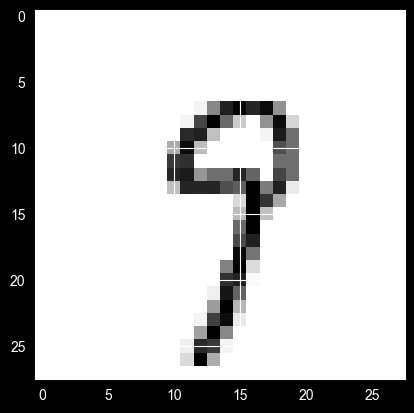

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,  51, 159, 253, 159,  50,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,  48, 238, 252, 252, 252, 237,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  

In [24]:
# Image
IMAGE_INDEX = 1500
plt.imshow(train_images[IMAGE_INDEX], cmap=plt.cm.binary)
plt.show()

train_labels[IMAGE_INDEX]
train_images[1]

In [25]:
# Prepare Data
train_images = train_images.reshape((60000, 28 * 28))
test_images = test_images.reshape((10000, 28 * 28))
train_images.shape

(60000, 784)

In [26]:
# Scale the inputs-data from 0-225 -> 0-1
train_images = train_images / 255.0
test_images = test_images / 255.0

In [27]:
# prepare labels
train_labels = to_categorical(train_labels)

In [28]:
train_labels[1]

array([1., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [29]:
train_images[1]

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.     

In [30]:
# 4) Build the model
import keras
ACTIVATION_FUNCTION = 'sigmoid'

model = models.Sequential([
    # INPUT LAYER (primera capa -izq-)
    keras.Input(shape=(28 * 28,)),

    # 1 hidden layer (capa oculta)
    #        q tantas neuronas, que tipo de activacion,
    keras.layers.Dense(512, activation=ACTIVATION_FUNCTION),

    # 2 hidden layer (capa oculta)
    keras.layers.Dense(128, activation=ACTIVATION_FUNCTION),

    # 3 output layer (capa de salida)
    keras.layers.Dense(10, activation=ACTIVATION_FUNCTION),
])

In [31]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 468,874 (1.79 MB)

 Trainable params: 468,874 (1.79 MB)

 Non-trainable params: 0 (0.00 B)

In [32]:
model.compile(loss = "categorical_crossentropy", optimizer='rmsprop', metrics=['accuracy'])

In [33]:
version = model.fit(train_images, train_labels, epochs=5, shuffle=True, validation_split=0.2)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8766 - loss: 0.4288 - val_accuracy: 0.9342 - val_loss: 0.2211
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9403 - loss: 0.1944 - val_accuracy: 0.9548 - val_loss: 0.1547
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9595 - loss: 0.1341 - val_accuracy: 0.9643 - val_loss: 0.1218
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9697 - loss: 0.0993 - val_accuracy: 0.9682 - val_loss: 0.1063
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9769 - loss: 0.0762 - val_accuracy: 0.9723 - val_loss: 0.0919


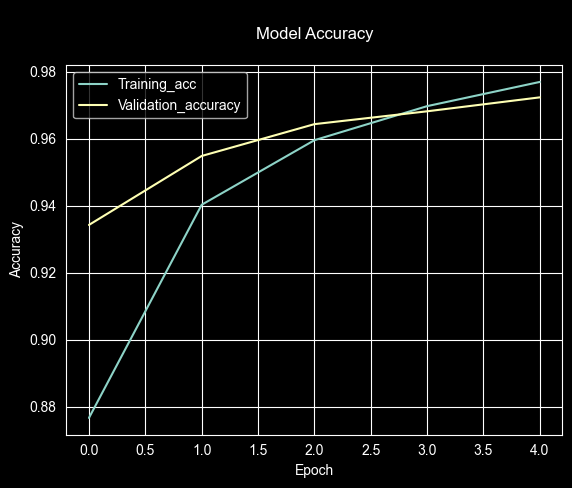

In [34]:
plt.plot(version.history['accuracy'])
plt.plot(version.history['val_accuracy'])
plt.legend(['Training_acc', 'Validation_accuracy'])
plt.title('\nModel Accuracy\n')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.show()

In [38]:
# Predictions
predict = model.predict(test_images)
rounded_pred = np.argmax(predict, axis=1)
for i in rounded_pred:
    print(i)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 981us/step
7
2
1
0
4
1
4
9
5
9
0
6
9
0
1
5
9
7
3
4
9
6
6
5
4
0
7
4
0
1
3
1
3
4
7
2
7
1
2
1
1
7
4
2
3
5
1
2
4
4
6
3
5
5
6
0
4
1
9
5
7
8
9
3
7
4
6
4
3
0
7
0
2
9
1
7
3
2
9
7
7
6
2
7
8
4
7
3
6
1
3
6
9
3
1
4
1
7
6
9
6
0
5
4
5
9
2
1
9
4
8
7
3
9
7
4
4
4
9
2
5
4
7
6
7
9
0
5
8
5
6
6
5
7
8
1
0
1
6
4
6
7
3
1
7
1
8
2
0
2
9
8
5
5
1
5
6
0
3
4
4
6
5
4
6
5
4
5
1
4
4
7
2
3
2
7
1
8
1
8
1
8
5
0
8
9
2
5
0
1
1
1
0
9
0
3
1
6
4
2
3
6
1
1
1
3
9
5
2
9
4
5
9
3
9
0
3
6
5
5
7
2
2
7
1
2
8
4
1
7
3
3
8
8
7
9
2
2
4
1
5
9
8
7
2
3
0
2
4
2
4
1
9
5
7
7
2
8
2
0
8
5
7
7
9
1
8
1
8
0
3
0
1
9
9
4
1
8
2
1
2
9
7
5
9
2
6
4
1
5
8
2
9
2
0
4
0
0
2
8
4
7
1
2
4
0
2
7
4
3
3
0
0
3
1
9
6
5
2
5
7
7
9
3
0
4
2
0
7
1
1
2
1
5
3
3
9
7
8
6
3
6
1
3
8
1
0
5
1
3
1
5
5
6
1
8
5
1
7
9
4
6
2
2
5
0
6
5
6
3
7
2
0
8
8
5
4
1
1
4
0
7
3
7
6
1
6
2
1
9
2
8
6
1
9
5
2
5
4
4
2
8
3
8
2
4
5
0
3
1
7
7
3
7
9
7
1
9
2
1
4
2
9
2
0
4
9
1
4
8
1
8
4
5
9
8
8
3
7
6
0
0
3
0
2
0
6
9
9
3
3
3
2
3
9
1
2
6
8
0
5
6
6
6
3
8
8
2
7
5
8
9
6
1
8
4
1
2
5

In [39]:
test_labels[1]

np.uint8(2)

In [40]:
predict[1]

array([2.4177174e-05, 1.0265953e-02, 9.1658163e-01, 6.5608504e-03,
       1.0275427e-07, 5.2405812e-05, 3.9334511e-04, 1.9013926e-06,
       6.5713184e-04, 5.9423478e-08], dtype=float32)

In [ ]:
# Confusion MAtrix
cm = confusion_matrix(test_labels, rounded_pred)
display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.arange(10))
display.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix")
plt.show()